【0. 数据集概览】
  总记录数: 792
  有活力记录数: 88
  有活力占比: 11.11%
✅ 有活力数据已导出至: active_records_analysis.xlsx

【1. 活力分布检验 (仅非零, n=88)】
  原始正态性 p=9.3998e-14 → ✗非正态
  对数正态性 p=3.3800e-03 → ✗非对数正态

  [未清理数据] KS拟合优度比较 (n=88):
    Normal      : D=0.2481, p=2.9491e-05
    Log-normal  : D=0.0680, p=7.8480e-01
    Gamma       : D=0.1311, p=8.8556e-02
    Weibull     : D=0.1427, p=5.0166e-02

  [清洗后数据] KS拟合优度比较 (n=82, 剔除6个异常值):
    Normal      : D=0.1594, p=2.7442e-02
    Log-normal  : D=0.0696, p=7.9530e-01 ← BEST
    Gamma       : D=0.0823, p=6.0500e-01
    Weibull     : D=0.0950, p=4.2361e-01

【3. 辅酶-活性卡方检验】
  χ²=1.547, p=2.1360e-01 → 无显著相关

【5. 底物类别 Kruskal-Wallis 检验】
  H=1.532, p=8.2093e-01 → 组间无显著差异


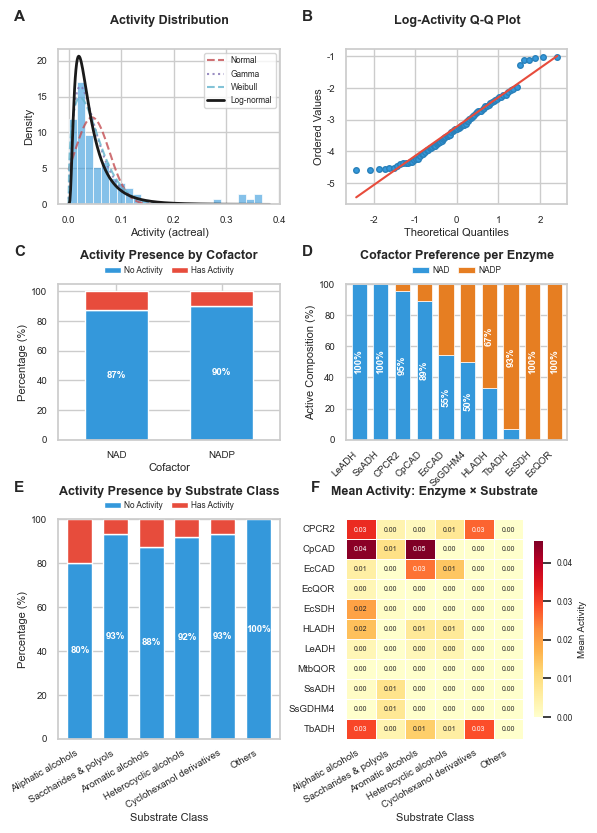


✅ 图表已保存: enzyme_activity_analysis.png
   设定尺寸: 5.85 × 7.50 inches (14.86 × 19.05 cm)
✅ 分析摘要已保存: analysis_summary.xlsx


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

SUBSTRATE_CATEGORIES = {
    range(1, 13): "Aliphatic alcohols",
    range(13, 21): "Saccharides & polyols",
    range(21, 25): "Aromatic alcohols",
    range(25, 29): "Heterocyclic alcohols",
    range(29, 33): "Cyclohexanol derivatives",
    range(33, 37): "Others"  
}

def classify_substrate(subnum: int) -> str:
    for rng, name in SUBSTRATE_CATEGORIES.items():
        if subnum in rng:
            return name
    return "Others"

def analyze_enzyme_dataset(filepath: str, config: dict):
    plt.rcParams['font.size'] = config['base']
    plt.rcParams['axes.titlesize'] = config['title']
    plt.rcParams['legend.fontsize'] = config['legend']
    plt.rcParams['legend.title_fontsize'] = config['legend_title']

    df = pd.read_excel(filepath)
    if 'actreal' not in df.columns and 'act' in df.columns:
        df = df.rename(columns={'act': 'actreal'})
        
    df["substrate_class"] = df["subnum"].apply(classify_substrate)
    df_active = df[df["actbool"] == 1].copy()
    nonzero_act = df_active["actreal"]
    
    print("=" * 60)
    print(f"【0. 数据集概览】")
    print(f"  总记录数: {len(df)}")
    print(f"  有活力记录数: {len(df_active)}")
    print(f"  有活力占比: {len(df_active)/len(df)*100:.2f}%")
    print("=" * 60)
    
    active_export = "active_records_analysis.xlsx"
    df_active.to_excel(active_export, index=False)
    print(f"✅ 有活力数据已导出至: {active_export}")
    
    results = {}
    
    # 使用 GridSpec 布局，通过 height_ratios 控制每行高度
    fig = plt.figure(figsize=(config['fig_width'], config['fig_height'])) 
    gs = gridspec.GridSpec(
        3, 2, figure=fig,
        height_ratios=config['height_ratios'],
        width_ratios=config['width_ratios'],
        hspace=config['h_pad'],
        wspace=config['w_pad']
    )
    
    # 辅助函数
    def format_ax(ax, label, title, xlabel, ylabel, show_x, show_y, legend_handles=None, legend_labels=None, legend_ncol=1):
        # 1. 独立字母标号
        offset = transforms.ScaledTranslation(0, config['subplot_label_y_offset']/72, fig.dpi_scale_trans)
        trans = ax.transAxes + offset
        ax.text(config['subplot_label_x_offset'], 1.0, label, transform=trans, 
                fontsize=config['subplot_label'], fontweight='bold', va='bottom', ha='left')
        
        # 2. 标题
        ax.set_title(title, fontweight='bold', pad=config['title_pad'])
        
        # 3. 轴标签及距离、可见性控制
        ax.set_xlabel(xlabel, fontsize=config['label_sizes'][label], 
                      labelpad=config['label_pads'][label], visible=show_x)
        ax.set_ylabel(ylabel, fontsize=config['label_sizes'][label], 
                      labelpad=config['label_pads'][label], visible=show_y)
                      
        # 4. 图例
        if legend_handles is not None:
            labels = legend_labels if legend_labels else [h.get_label() for h in legend_handles]
            ax.legend(handles=legend_handles, labels=labels, loc='lower center', 
                      bbox_to_anchor=(0.5, 1.01), ncol=legend_ncol, 
                      framealpha=0.9, edgecolor='none', columnspacing=1.0, handletextpad=0.4)

    # 堆叠柱状图数字标注辅助函数 (彻底修正索引逻辑)
    def add_stacked_bar_labels(ax, df_pct, rotation=0, threshold=3):
        cols = df_pct.columns
        patches = ax.patches
        n_cats = len(df_pct)
        
        # Pandas stacked bar patches 顺序: 
        # 前 n_cats 个是底部系列(col 0)，后 n_cats 个是顶部系列(col 1)
        for i, (idx, row) in enumerate(df_pct.iterrows()):
            val0 = row[cols[0]]
            val1 = row[cols[1]]
            
            if val0 >= val1:
                show_val = val0
                target_patch = patches[i]           # 底部柱子
            else:
                show_val = val1
                target_patch = patches[i + n_cats]  # 顶部柱子
                
            if show_val > threshold:
                x_center = target_patch.get_x() + target_patch.get_width() / 2
                y_center = target_patch.get_y() + target_patch.get_height() / 2
                
                ax.text(x_center, y_center, f'{show_val:.0f}%', 
                        ha='center', va='center', fontsize=config['bar_text'], 
                        color='white', fontweight='bold', rotation=rotation)

    # ==========================
    # 1. 活力分布分析与多分布拟合 (图A)
    # ==========================
    ax1 = fig.add_subplot(gs[0, 0])
    
    log_act = np.log(nonzero_act)
    Q1_log, Q3_log = np.percentile(log_act, [25, 75])
    IQR_log = Q3_log - Q1_log
    upper_fence_log = Q3_log + 1.5 * IQR_log
    mask_log = log_act <= upper_fence_log
    
    Q1_raw, Q3_raw = nonzero_act.quantile([0.25, 0.75])
    IQR_raw = Q3_raw - Q1_raw
    upper_fence_raw = Q3_raw + 3.0 * IQR_raw
    mask_raw = nonzero_act <= upper_fence_raw
    
    mask_clean = mask_log & mask_raw
    nonzero_act_clean = nonzero_act[mask_clean]
    outliers_count = len(nonzero_act) - len(nonzero_act_clean)
    
    test_normal = stats.shapiro(nonzero_act) if len(nonzero_act) <= 5000 else stats.normaltest(nonzero_act)
    test_log = stats.shapiro(log_act) if len(log_act) <= 5000 else stats.normaltest(log_act)
    
    print(f"\n【1. 活力分布检验 (仅非零, n={len(nonzero_act)})】")
    print(f"  原始正态性 p={test_normal.pvalue:.4e} → {'✓正态' if test_normal.pvalue > 0.05 else '✗非正态'}")
    print(f"  对数正态性 p={test_log.pvalue:.4e} → {'✓对数正态' if test_log.pvalue > 0.05 else '✗非对数正态'}")
    
    mu_norm_raw, sigma_norm_raw = stats.norm.fit(nonzero_act)
    shape_log_raw, loc_log_raw, scale_log_raw = stats.lognorm.fit(nonzero_act, floc=0)
    gamma_params_raw = stats.gamma.fit(nonzero_act, floc=0)
    weibull_params_raw = stats.weibull_min.fit(nonzero_act, floc=0)
    
    ks_raw = {
        "Normal": stats.kstest(nonzero_act, "norm", args=(mu_norm_raw, sigma_norm_raw)),
        "Log-normal": stats.kstest(nonzero_act, "lognorm", args=(shape_log_raw, loc_log_raw, scale_log_raw)),
        "Gamma": stats.kstest(nonzero_act, "gamma", args=gamma_params_raw),
        "Weibull": stats.kstest(nonzero_act, "weibull_min", args=weibull_params_raw),
    }
    print(f"\n  [未清理数据] KS拟合优度比较 (n={len(nonzero_act)}):")
    for name, ks in ks_raw.items():
        print(f"    {name:12s}: D={ks.statistic:.4f}, p={ks.pvalue:.4e}")

    mu_norm, sigma_norm = stats.norm.fit(nonzero_act_clean)
    shape_log, loc_log, scale_log = stats.lognorm.fit(nonzero_act_clean, floc=0)
    gamma_params = stats.gamma.fit(nonzero_act_clean, floc=0)
    weibull_params = stats.weibull_min.fit(nonzero_act_clean, floc=0)
    
    ks_results = {
        "Normal": stats.kstest(nonzero_act_clean, "norm", args=(mu_norm, sigma_norm)),
        "Log-normal": stats.kstest(nonzero_act_clean, "lognorm", args=(shape_log, loc_log, scale_log)),
        "Gamma": stats.kstest(nonzero_act_clean, "gamma", args=gamma_params),
        "Weibull": stats.kstest(nonzero_act_clean, "weibull_min", args=weibull_params),
    }
    best_dist = min(ks_results, key=lambda k: ks_results[k].statistic)
    
    print(f"\n  [清洗后数据] KS拟合优度比较 (n={len(nonzero_act_clean)}, 剔除{outliers_count}个异常值):")
    for name, ks in ks_results.items():
        marker = " ← BEST" if name == best_dist else ""
        print(f"    {name:12s}: D={ks.statistic:.4f}, p={ks.pvalue:.4e}{marker}")
    
    results["distribution_fit_raw"] = {k: {"D": v.statistic, "p": v.pvalue} for k, v in ks_raw.items()}
    results["distribution_fit_clean"] = {k: {"D": v.statistic, "p": v.pvalue} for k, v in ks_results.items()}
    results["best_distribution"] = best_dist
    results["outlier_count"] = outliers_count
    
    x_max = nonzero_act.max() * 1.05
    sns.histplot(nonzero_act, bins=25, kde=False, stat="density", ax=ax1, 
                 color="#3498db", alpha=0.6, edgecolor='white', linewidth=0.5, binrange=(0, x_max))
    
    x_range = np.linspace(0, x_max, 300)
    l1, = ax1.plot(x_range, stats.norm.pdf(x_range, mu_norm, sigma_norm), 'r--', lw=1.5, alpha=0.8, label='Normal')
    l2, = ax1.plot(x_range, stats.gamma.pdf(x_range, *gamma_params), 'm:', lw=1.5, alpha=0.8, label='Gamma')
    l3, = ax1.plot(x_range, stats.weibull_min.pdf(x_range, *weibull_params), 'c--', lw=1.5, alpha=0.8, label='Weibull')
    l4, = ax1.plot(x_range, stats.lognorm.pdf(x_range, shape_log, loc_log, scale_log), 'k-', lw=2, label='Log-normal')
    
    format_ax(ax1, 'A', "Activity Distribution", "Activity (actreal)", "Density",
              config['show_labels']['A'][0], config['show_labels']['A'][1])
    ax1.legend(handles=[l1, l2, l3, l4], loc='upper right', framealpha=0.8, fontsize=config['legend'])
    
    # ==========================
    # 2. 异常值分析 (Q-Q Plot) (图B)
    # ==========================
    ax2 = fig.add_subplot(gs[0, 1])
    stats.probplot(np.log(nonzero_act), dist="norm", plot=ax2)
    ax2.get_lines()[0].set(markerfacecolor='#3498db', markeredgecolor='#2980b9', markersize=4)
    ax2.get_lines()[1].set(color='#e74c3c', linewidth=1.5)
    
    format_ax(ax2, 'B', "Log-Activity Q-Q Plot", "Theoretical Quantiles", "Ordered Values",
              config['show_labels']['B'][0], config['show_labels']['B'][1])
    
    # ==========================
    # 3. 辅酶 vs 活性有无 (图C)
    # ==========================
    ax3 = fig.add_subplot(gs[1, 0])
    cofactor_ct = df.groupby(["cofactor", "actbool"]).size().unstack(fill_value=0)
    cofactor_pct = cofactor_ct.div(cofactor_ct.sum(axis=1), axis=0) * 100
    
    if 0 in cofactor_pct.columns and 1 in cofactor_pct.columns:
        cofactor_pct = cofactor_pct[[0, 1]]
    
    cofactor_pct.plot(kind="bar", stacked=True, ax=ax3, color=["#3498db", "#e74c3c"], width=0.6, legend=False)
    handles3, _ = ax3.get_legend_handles_labels()
    labels3 = ["No Activity", "Has Activity"]
    
    add_stacked_bar_labels(ax3, cofactor_pct, rotation=0)
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
    
    format_ax(ax3, 'C', "Activity Presence by Cofactor", "Cofactor", "Percentage (%)",
              config['show_labels']['C'][0], config['show_labels']['C'][1],
              legend_handles=handles3, legend_labels=labels3, legend_ncol=2)
    
    contingency = df.pivot_table(index="cofactor", columns="actbool", aggfunc="size", fill_value=0)
    chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
    print(f"\n【3. 辅酶-活性卡方检验】")
    print(f"  χ²={chi2:.3f}, p={p_chi:.4e} → {'显著相关' if p_chi < 0.05 else '无显著相关'}")
    results["cofactor_chi2"] = {"chi2": chi2, "p_value": p_chi}
    
    # ==========================
    # 4. 各酶辅酶偏好 (图D)
    # ==========================
    ax4 = fig.add_subplot(gs[1, 1])
    enzyme_cofactor = df_active.groupby(["enzyme", "cofactor"]).size().unstack(fill_value=0)
    enzyme_cofactor_pct = enzyme_cofactor.div(enzyme_cofactor.sum(axis=1), axis=0) * 100
    
    for col in ["NAD", "NADP"]:
        if col not in enzyme_cofactor_pct.columns:
            enzyme_cofactor_pct[col] = 0
            
    enzyme_cofactor_pct = enzyme_cofactor_pct.sort_values(by="NAD", ascending=False)
    
    enzyme_cofactor_pct[["NAD", "NADP"]].plot(
        kind="bar", stacked=True, ax=ax4, color=["#3498db", "#e67e22"],
        width=0.7, edgecolor='white', linewidth=0.5, legend=False
    )
    handles4, labels4 = ax4.get_legend_handles_labels()
    
    add_stacked_bar_labels(ax4, enzyme_cofactor_pct[["NAD", "NADP"]], rotation=90)
    ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
    ax4.set_ylim(0, 100)
                     
    format_ax(ax4, 'D', "Cofactor Preference per Enzyme", "Enzyme", "Active Composition (%)",
              config['show_labels']['D'][0], config['show_labels']['D'][1],
              legend_handles=handles4, legend_labels=labels4, legend_ncol=2)
    
    # ==========================
    # 5. 底物类别 vs 活性有无 (图E)
    # ==========================
    ax5 = fig.add_subplot(gs[2, 0])
    cat_order = [
        "Aliphatic alcohols", "Saccharides & polyols", "Aromatic alcohols",
        "Heterocyclic alcohols", "Cyclohexanol derivatives", "Others"
    ]
    cat_ct = df.groupby(["substrate_class", "actbool"]).size().unstack(fill_value=0).reindex(cat_order)
    cat_pct = cat_ct.div(cat_ct.sum(axis=1), axis=0) * 100
    
    for cat in cat_order:
        if cat not in cat_pct.index:
            cat_pct.loc[cat] = [0, 0]
            
    if 0 in cat_pct.columns and 1 in cat_pct.columns:
        cat_pct = cat_pct[[0, 1]]
        
    cat_pct.plot(kind="bar", stacked=True, ax=ax5, color=["#3498db", "#e74c3c"], width=0.7, legend=False)
    handles5, _ = ax5.get_legend_handles_labels()
    labels5 = ["No Activity", "Has Activity"]
    
    add_stacked_bar_labels(ax5, cat_pct, rotation=0)
    ax5.set_xticklabels(ax5.get_xticklabels(), rotation=30, ha='right')
    ax5.set_ylim(0, 100)
    
    format_ax(ax5, 'E', "Activity Presence by Substrate Class", "Substrate Class", "Percentage (%)",
              config['show_labels']['E'][0], config['show_labels']['E'][1],
              legend_handles=handles5, legend_labels=labels5, legend_ncol=2)
    
    groups = [g["actreal"].values for _, g in df_active.groupby("substrate_class")]
    if len(groups) >= 2 and all(len(g) > 0 for g in groups):
        kw_stat, kw_p = stats.kruskal(*groups)
        print(f"\n【5. 底物类别 Kruskal-Wallis 检验】")
        print(f"  H={kw_stat:.3f}, p={kw_p:.4e} → {'组间存在显著差异' if kw_p < 0.05 else '组间无显著差异'}")
        results["substrate_kw"] = {"H": kw_stat, "p": kw_p}
    
    # ==========================
    # 6. 酶 × 底物类别 热力图 (图F)
    # ==========================
    ax6 = fig.add_subplot(gs[2, 1])
    heatmap_data = df.groupby(["enzyme", "substrate_class"])["actreal"].mean().unstack().reindex(columns=cat_order)
    
    fmt_str = f".{config['heatmap_decimals']}f"
    sns.heatmap(heatmap_data, annot=config['heatmap_annot'], fmt=fmt_str, cmap="YlOrRd", ax=ax6, linewidths=0.5, 
                cbar_kws={'label': 'Mean Activity', 'shrink': 0.8}, 
                annot_kws={"size": config['heatmap_annot_size']})
    
    cbar = ax6.collections[0].colorbar
    cbar.ax.tick_params(labelsize=config['cbar_tick_size'])
    cbar.set_label('Mean Activity', size=config['cbar_label_size'])
    
    plt.setp(ax6.get_xticklabels(), rotation=30, ha='right')
    plt.setp(ax6.get_yticklabels(), rotation=0)
    
    format_ax(ax6, 'F', "Mean Activity: Enzyme × Substrate", "Substrate Class", "Enzyme",
              config['show_labels']['F'][0], config['show_labels']['F'][1])
    
    # ==========================
    # 全局后置处理：强制应用刻度距离 (防止被 seaborn 覆盖)
    # ==========================
    axes_map = {'A': ax1, 'B': ax2, 'C': ax3, 'D': ax4, 'E': ax5, 'F': ax6}
    for lbl, ax in axes_map.items():
        ax.tick_params(axis='both', labelsize=config['tick_sizes'][lbl])
        ax.tick_params(axis='x', pad=config['tick_pads'][lbl]['x'])
        ax.tick_params(axis='y', pad=config['tick_pads'][lbl]['y'])

    # 调整布局并保存
    plt.subplots_adjust(
        top=1 - config['margin_top'], 
        bottom=config['margin_bottom'], 
        left=config['margin_left'], 
        right=1 - config['margin_right']
    )

    fig_path = "enzyme_activity_analysis.png"
    #plt.savefig(fig_path, dpi=300, bbox_inches='tight', pad_inches=0.1) 


    plt.savefig(os.path.join("figures", "Figure2.png"), dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.savefig(os.path.join("figures", "Figure2.tif"), dpi=300, bbox_inches='tight', pad_inches=0.1)

    
    plt.show()
    
    save_w_inch = config['fig_width']
    save_h_inch = config['fig_height']
    print(f"\n✅ 图表已保存: {fig_path}")
    print(f"   设定尺寸: {save_w_inch:.2f} × {save_h_inch:.2f} inches ({save_w_inch * 2.54:.2f} × {save_h_inch * 2.54:.2f} cm)")
    
    summary_rows = [
        {"Metric": "Total records", "Value": len(df)},
        {"Metric": "Active records", "Value": len(df_active)},
        {"Metric": "Active ratio", "Value": f"{len(df_active)/len(df)*100:.1f}%"},
        {"Metric": "Best fit distribution (cleaned)", "Value": best_dist},
        {"Metric": "Outliers removed", "Value": outliers_count}
    ]
    for name, ks in ks_results.items():
        summary_rows.append({"Metric": f"KS-Clean-{name} (D/p)", "Value": f"{ks.statistic:.4f}/{ks.pvalue:.4e}"})
    for name, ks in ks_raw.items():
        summary_rows.append({"Metric": f"KS-Raw-{name} (D/p)", "Value": f"{ks.statistic:.4f}/{ks.pvalue:.4e}"})
    summary_rows.append({"Metric": "Cofactor χ² p-value", "Value": f"{p_chi:.4e}"})
    if "substrate_kw" in results:
        summary_rows.append({"Metric": "Substrate KW p-value", "Value": f"{results['substrate_kw']['p']:.4e}"})
        
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_excel("analysis_summary.xlsx", index=False)
    print("✅ 分析摘要已保存: analysis_summary.xlsx")
    
    return results, df_active


# ==========================
# 主程序入口与全局参数配置
# ==========================
if __name__ == "__main__":
    plt.rcParams['font.sans-serif'] = ['Arial', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.unicode_minus'] = False
    sns.set_theme(style="whitegrid", font_scale=1.0, font="Arial") 

    CONFIG = {
        # --- 画布尺寸 ---
        'fig_width': 5.85,         # 画布宽度 (inches, < 15cm)
        'fig_height': 7.5,        # 画布总高度 (inches, 可自由调节)
        
        # --- 子图行列比例控制 (替代失效的 aspect) ---
        # 控制 3 行的相对高度。例如 [1.0, 0.5, 1.0] 表示第2行(图C/D)高度被压扁为第1行的一半
        'height_ratios': [1.0, 1, 1.41], 
        # 控制 2 列的相对宽度。
        'width_ratios': [1.0, 1.0],       
        
        # --- 边距与间距 ---
        'margin_top': 0.02,        
        'margin_bottom': 0.06,     
        'margin_left': 0.08,       
        'margin_right': 0.05,      
        'h_pad': 0.45,             # 纵向子图间距 
        'w_pad': 0.3,             # 横向子图间距 
        
        # --- 全局字号 ---
        'base': 7,                 
        'title': 9,                
        'legend': 6,               
        'legend_title': 6,         
        'bar_text': 7,             
        
        # --- 字母标号设置 ---
        'subplot_label': 11,       
        'subplot_label_x_offset': -0.2, 
        'subplot_label_y_offset': 18,    
        
        # --- 标题与图的距离 ---
        'title_pad': 18,           
        
        # --- 热图 (图F) 专属设置 ---
        'heatmap_annot': True,     
        'heatmap_annot_size': 5,   
        'heatmap_decimals': 2,     
        'cbar_tick_size': 6,       
        'cbar_label_size': 7,      
        
        # --- 每张图的坐标轴标签字号 ---
        'label_sizes': {
            'A': 8, 'B': 8, 'C': 8, 'D': 8, 'E': 8, 'F': 8
        },
        
        # --- 每张图的坐标轴刻度字号 ---
        'tick_sizes': {
            'A': 7, 'B': 7, 'C': 7, 'D': 7, 'E': 7, 'F': 7
        },
        
        # --- 每张图的坐标轴标签与刻度标签的距离 (labelpad) ---
        'label_pads': {
            'A': 2, 'B': 2, 'C': 2, 'D': 2, 'E': 2, 'F': 2
        },
        
        # --- 每张图的刻度标签与坐标轴线的距离 (X/Y轴独立控制) ---
        'tick_pads': {
            'A': {'x': 2.0, 'y': 2.0}, 
            'B': {'x': 2.0, 'y': 2.0}, 
            'C': {'x': 2.0, 'y': 2.0}, 
            'D': {'x': 1.0, 'y': 2.0}, 
            'E': {'x': 1.0, 'y': 2.0}, 
            'F': {'x': 1.0, 'y': 2.0}
        },
        
        # --- 每个图的横纵坐标轴标签是否显示 ---
        'show_labels': {
            'A': [True, True],
            'B': [True, True],
            'C': [True, True],
            'D': [False, True],
            'E': [True, True],
            'F': [True, False]
        }
    }

    results, active_df = analyze_enzyme_dataset("sum.xlsx", config=CONFIG)